# This notebook is for making figure 1 of the paper.
- A). Schematic of the model (No plots in this notebook)
- B). KEGG of new metabolic genes
- C). Distribution of new reaction flux to show that they are just low flux reactions. --> indicating the problem
- D). Problem solution

In [1]:
import os

import requests
import pandas as pd
from pathlib import Path
import ast

## B). KEGG of new metabolic genes

In [2]:
outdir = Path("out/new_genes_functionality")
outdir.mkdir(exist_ok=True)

tmpdir = Path("tmp")
tmpdir.mkdir(exist_ok=True)

csv_path = Path("new_metabolic_gene_annotation.csv")
df = pd.read_csv(csv_path)

for col in ["Reactions", "MultiFuntional name"]:
    df[col] = df[col].apply(
        lambda x: ast.literal_eval(x)
        if isinstance(x, str) and x.strip().startswith("[")
        else x
    )

study_ecocyc_ids  = set(df["Gene ID (EcoCyc)"].dropna().str.strip())
study_locus_ids   = set(df["Gene locus ID"].dropna().str.strip())
study_gene_names  = set(df["Gene name"].dropna().str.strip().str.lower())

locus_id_to_ecocyc = dict(zip(df["Gene locus ID"].dropna().str.strip(), df["Gene ID (EcoCyc)"].dropna().str.strip()))

print(f"Loaded {len(df)} gene annotations")
print(f"  EcoCyc IDs : {len(study_ecocyc_ids)}")
print(f"  Locus IDs  : {len(study_locus_ids)}")
print(f"  Gene names : {len(study_gene_names)}")
df.head(3)

Loaded 307 gene annotations
  EcoCyc IDs : 307
  Locus IDs  : 307
  Gene names : 307


,Gene ID (EcoCyc),Gene locus ID,Gene name,Enzyme encoded,Pathways,Pathways parent,Protein products,MultiFuntional ID,MultiFuntional name,Reactions,Description by Cyrus
0,EG10022,b4015,aceA,ISOCIT-LYASE,GLYOXYLATE-BYPASS,Energy-Metabolism,ISOCIT-LYASE-MONOMER,BC-1.7.2,[metabolism -> central intermediary metabolism...,[ISOCIT-CLEAV-RXN],acetate transport + metabolism
1,EG10023,b4014,aceB,MALATE-SYNTHASE,GLYOXYLATE-BYPASS,Energy-Metabolism,MALATE-SYNTHASE,BC-1.7.2,[metabolism -> central intermediary metabolism...,[MALSYN-RXN],acetate transport + metabolism
2,EG11942,b4067,actP,CPLX0-7955,NaN,NaN,YJCG-MONOMER,"['BC-4.2.A', 'BC-6.1']",[transport -> Electrochemical potential driven...,"[RXN0-1981, RXN0-5111, TRANS-RXN0-576]",acetate transport + metabolism


In [3]:
kegg_link_path = tmpdir / "kegg_eco_pathway_genes.tsv"
kegg_list_path = tmpdir / "kegg_eco_pathway_names.tsv"

def _kegg_get(url, cache_path, label):
    if not cache_path.exists():
        print(f"Downloading {label}...")
        try:
            r = requests.get(url, timeout=90)
            r.raise_for_status()
            cache_path.write_text(r.text, encoding="utf-8")
            print(f"  {len(r.text.splitlines())} entries saved to {cache_path}")
            return cache_path
        except Exception as e:
            print(f"  WARNING: {e}")
            return None
    else:
        print(f"Using cached {label}: {cache_path}")
        return cache_path

kegg_link_path = _kegg_get(
    "https://rest.kegg.jp/link/eco/pathway", kegg_link_path, "KEGG pathway-gene links"
)
kegg_list_path = _kegg_get(
    "https://rest.kegg.jp/list/pathway/eco", kegg_list_path, "KEGG pathway names"
)

kegg_link_df    = pd.DataFrame()
pathway_name_map = {}
kegg_study_genes = set()
kegg_background  = set()

if kegg_link_path is not None:
    kegg_link_df = pd.read_csv(
        kegg_link_path, sep="\t", header=None, names=["pathway_id", "gene_id"]
    )
    # gene_id format: eco:b4015 → strip prefix
    kegg_link_df["locus_id"]      = kegg_link_df["gene_id"].str.replace("eco:", "", regex=False)
    kegg_link_df["pathway_short"] = kegg_link_df["pathway_id"].str.replace("path:", "", regex=False)
    kegg_background = set(kegg_link_df["locus_id"].unique())
    kegg_study_genes = study_locus_ids & kegg_background
    print(f"KEGG: {kegg_link_df['pathway_short'].nunique()} pathways, "
          f"{len(kegg_background)} background genes")
    print(f"Study genes matched: {len(kegg_study_genes)} / {len(study_locus_ids)}")

if kegg_list_path is not None:
    names_df = pd.read_csv(kegg_list_path, sep="\t", header=None, names=["pathway_id", "pathway_name"])
    names_df["pathway_short"] = names_df["pathway_id"].str.replace("path:", "", regex=False)
    pathway_name_map = dict(zip(names_df["pathway_short"], names_df["pathway_name"]))
    print(f"Loaded {len(pathway_name_map)} pathway names")

Using cached KEGG pathway-gene links: tmp/kegg_eco_pathway_genes.tsv
Using cached KEGG pathway names: tmp/kegg_eco_pathway_names.tsv
KEGG: 137 pathways, 1785 background genes
Study genes matched: 206 / 307
Loaded 137 pathway names


In [4]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

kegg_enrich_df = pd.DataFrame()

if not kegg_link_df.empty and len(kegg_study_genes) > 0:
    N = len(kegg_background)
    K = len(kegg_study_genes)

    rows = []
    for pw, grp in kegg_link_df.groupby("pathway_short"):
        pw_genes = set(grp["locus_id"])
        a = len(kegg_study_genes & pw_genes)  # study in pathway
        b = len(pw_genes) - a                  # pop-only in pathway
        c = K - a                               # study not in pathway
        d = N - K - b                           # pop-only, not in pathway
        if a == 0:
            continue
        _, pval = fisher_exact([[a, b], [c, max(d, 0)]], alternative="greater")
        rows.append({
            "pathway_id":       pw,
            "pathway_name":     pathway_name_map.get(pw, pw),
            "study_in_pathway": a,
            "pathway_size":     len(pw_genes),
            "geneRatio":       a/len(pw_genes),
            "p_value":          pval,
        })

    kegg_enrich_df = pd.DataFrame(rows)
    if not kegg_enrich_df.empty:
        _, fdr, _, _ = multipletests(kegg_enrich_df["p_value"], method="fdr_bh")
        kegg_enrich_df["p_fdr"] = fdr
        kegg_enrich_df = kegg_enrich_df.sort_values("p_fdr")
        sig_k = kegg_enrich_df[kegg_enrich_df["p_fdr"] < 0.05]
        print(f"KEGG pathways tested: {len(kegg_enrich_df)}, significant (FDR<0.05): {len(sig_k)}")
        print("\nTop 15 KEGG pathways:")
        print(kegg_enrich_df.head(15)[
            ["pathway_name", "study_in_pathway", "geneRatio","pathway_size", "p_fdr"]
        ].to_string(index=False))
else:
    print("Skipping KEGG enrichment: no data.")

KEGG pathways tested: 70, significant (FDR<0.05): 13

Top 15 KEGG pathways:
                                                          pathway_name  study_in_pathway  geneRatio  pathway_size    p_fdr
        Phosphotransferase system (PTS) - Escherichia coli K-12 MG1655                19   0.441860            43 0.000003
 Phosphonate and phosphinate metabolism - Escherichia coli K-12 MG1655                 7   0.875000             8 0.000042
                       ABC transporters - Escherichia coli K-12 MG1655                42   0.234637           179 0.000042
      Degradation of aromatic compounds - Escherichia coli K-12 MG1655                10   0.588235            17 0.000056
         Exopolysaccharide biosynthesis - Escherichia coli K-12 MG1655                 8   0.533333            15 0.001212
                    Folate biosynthesis - Escherichia coli K-12 MG1655                10   0.384615            26 0.003388
               Nitrotoluene degradation - Escherichia coli K-12

In [5]:
print(f'Genes that don\'t have KEGG association: {study_locus_ids.difference(study_locus_ids & kegg_background)}')

Genes that don't have KEGG association: {'b1661', 'b1418', 'b2134', 'b1490', 'b1616', 'b1590', 'b4115', 'b2194', 'b2552', 'b3258', 'b1192', 'b3824', 'b0872', 'b2202', 'b2529', 'b2711', 'b0336', 'b3005', 'b3692', 'b0150', 'b0353', 'b0038', 'b1519', 'b2536', 'b2480', 'b3909', 'b0902', 'b2710', 'b2871', 'b4228', 'b2046', 'b3435', 'b1252', 'b3127', 'b3653', 'b4036', 'b2051', 'b3063', 'b2587', 'b2995', 'b0037', 'b3946', 'b3370', 'b0099', 'b3714', 'b0039', 'b0605', 'b1324', 'b2492', 'b3081', 'b2196', 'b2503', 'b1449', 'b2328', 'b2197', 'b2240', 'b3781', 'b0476', 'b2690', 'b4356', 'b3610', 'b4073', 'b1773', 'b3415', 'b4265', 'b0621', 'b0825', 'b4291', 'b2205', 'b1592', 'b2996', 'b1400', 'b1589', 'b4072', 'b2195', 'b3691', 'b3656', 'b4120', 'b2835', 'b3966', 'b2204', 'b0040', 'b1489', 'b1794', 'b2365', 'b1981', 'b3006', 'b2923', 'b0036', 'b2385', 'b0751', 'b0805', 'b3792', 'b0591', 'b1102', 'b2789', 'b0849', 'b0341', 'b0260', 'b0110', 'b4067'}


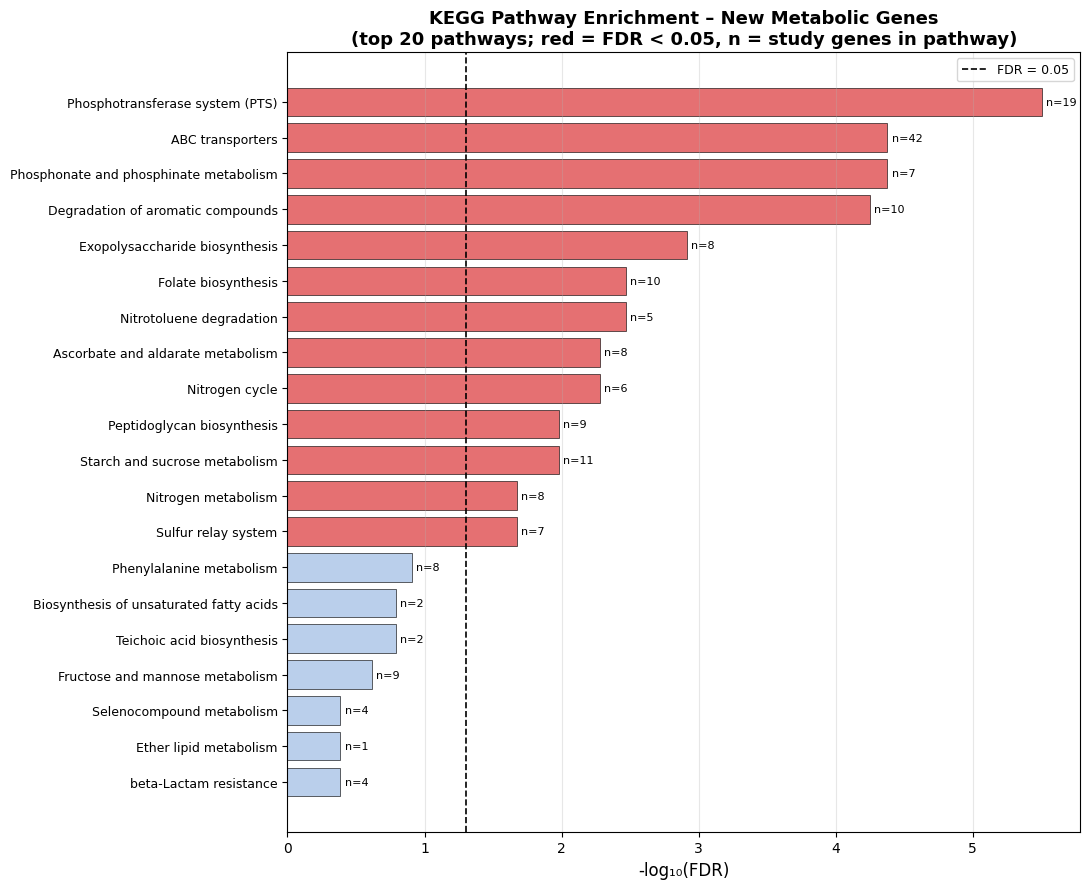

Saved: out/new_genes_functionality/kegg_enrichment.svg


In [65]:
import matplotlib.pyplot as plt
import numpy as np

if not kegg_enrich_df.empty:
    top20 = kegg_enrich_df.head(20).copy().sort_values("p_fdr", ascending=False)
    top20["log_p"] = -np.log10(top20["p_fdr"].clip(lower=1e-300))

    colors = ["#e15759" if p < 0.05 else "#aec7e8" for p in top20["p_fdr"]]

    fig, ax = plt.subplots(figsize=(11, 9))
    ax.barh(range(len(top20)), top20["log_p"],
            color=colors, edgecolor="black", linewidth=0.5, alpha=0.85)

    for i, (_, row) in enumerate(top20.iterrows()):
        ax.text(row["log_p"] + 0.03, i, f"n={int(row['study_in_pathway'])}",
                va="center", fontsize=8)

    clean_names = []
    for name in top20["pathway_name"]:
        short = name.split(" - ")[0] if " - " in name else name
        clean_names.append(short[:62] + "…" if len(short) > 62 else short)

    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(clean_names, fontsize=9)
    ax.set_xlabel("-log\u2081\u2080(FDR)", fontsize=12)
    ax.set_title(
        "KEGG Pathway Enrichment – New Metabolic Genes\n"
        "(top 20 pathways; red = FDR < 0.05, n = study genes in pathway)",
        fontsize=13, fontweight="bold",
    )
    ax.axvline(-np.log10(0.05), color="black", ls="--", lw=1.2, label="FDR = 0.05")
    ax.legend(fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    save_path = outdir / "kegg_enrichment.svg"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
else:
    print("No KEGG results to visualise.")

### GO Enrichment

In [6]:
import requests, gzip, io

gaf_path = tmpdir / "ecocyc.gaf"
obo_path = tmpdir / "go-basic.obo"

if not gaf_path.exists():
    print("Downloading EcoCyc GAF annotation file...")
    try:
        r = requests.get(
            "http://current.geneontology.org/annotations/ecocyc.gaf.gz",
            timeout=180,
        )
        r.raise_for_status()
        with gzip.open(io.BytesIO(r.content)) as fgz:
            content = fgz.read()
        gaf_path.write_bytes(content)
        print(f"  Saved {gaf_path} ({gaf_path.stat().st_size // 1024} KB)")
    except Exception as e:
        print(f"  WARNING: GAF download failed: {e}")
        gaf_path = None
else:
    print(f"Using cached GAF: {gaf_path}")

if not obo_path.exists():
    print("Downloading GO OBO file...")
    try:
        r = requests.get(
            "http://purl.obolibrary.org/obo/go/go-basic.obo",
            timeout=180,
        )
        r.raise_for_status()
        obo_path.write_bytes(r.content)
        print(f"  Saved {obo_path} ({obo_path.stat().st_size // 1024} KB)")
    except Exception as e:
        print(f"  WARNING: OBO download failed: {e}")
        obo_path = None
else:
    print(f"Using cached OBO: {obo_path}")

Using cached GAF: tmp/ecocyc.gaf
Using cached OBO: tmp/go-basic.obo


In [7]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import pandas as pd

GO_COLS = ["go_id", "term", "namespace", "study_count",
           "pop_count", "p_value", "GeneRatio", "p_fdr_bh"]
go_df = pd.DataFrame(columns=GO_COLS)
go_study_n = 0

if gaf_path is not None and obo_path is not None:
    # ── Parse GO OBO → {go_id: {name, namespace}} ────────────────────────
    ns_map = {
        "biological_process": "BP",
        "molecular_function": "MF",
        "cellular_component": "CC",
    }

    def _flush_term(current, go_info):
        if current is None:
            return
        gid = current.get("id", "")
        if gid.startswith("GO:") and not current.get("obsolete"):
            go_info[gid] = {
                "name": current.get("name", ""),
                "namespace": ns_map.get(current.get("namespace", ""), "?"),
            }

    go_info = {}
    current = None
    with open(obo_path) as fh:
        for line in fh:
            line = line.rstrip()
            if line == "[Term]":
                _flush_term(current, go_info)
                current = {}
            elif line.startswith("[") and current is not None:
                _flush_term(current, go_info)
                current = None
            elif current is not None:
                if line.startswith("id: "):
                    current["id"] = line[4:]
                elif line.startswith("name: "):
                    current["name"] = line[6:]
                elif line.startswith("namespace: "):
                    current["namespace"] = line[11:]
                elif "is_obsolete: true" in line:
                    current["obsolete"] = True
    _flush_term(current, go_info)
    print(f"GO terms loaded from OBO: {len(go_info)}")

    # ── Parse GAF → {gene_name_lower: set(go_ids)} ────────────────────────
    pop_go = {}
    with open(gaf_path) as fh:
        for line in fh:
            if line.startswith("!"):
                continue
            parts = line.rstrip().split("\t")
            if len(parts) < 9:
                continue
            if "NOT" in parts[3]:
                continue
            gene_sym = parts[2].lower()
            go_id = parts[4]
            if go_id not in go_info:
                continue
            pop_go.setdefault(gene_sym, set()).add(go_id)

    study_go = {g: pop_go[g] for g in study_gene_names if g in pop_go}
    go_study_n = len(study_go)
    go_pop_n = len(pop_go)
    print(
        f"Background genes with GO: {go_pop_n}, "
        f"Study genes with GO: {go_study_n}/{len(study_gene_names)}"
    )

    # ── Inverted indices: go_id → gene sets ───────────────────────────────
    go_to_pop = {}
    for gene, gos in pop_go.items():
        for gid in gos:
            go_to_pop.setdefault(gid, set()).add(gene)

    go_to_study = {}
    for gene, gos in study_go.items():
        for gid in gos:
            go_to_study.setdefault(gid, set()).add(gene)

    # ── Fisher's exact test per GO term ───────────────────────────────────
    N = go_pop_n
    K_go = go_study_n
    rows_go = []
    for go_id, study_genes_in in go_to_study.items():
        info = go_info.get(go_id)
        if info is None:
            continue
        a = len(study_genes_in)
        M = len(go_to_pop.get(go_id, set()))
        b = M - a
        c = K_go - a
        d = N - K_go - b
        _, pval = fisher_exact([[a, b], [c, max(d, 0)]], alternative="greater")
        rows_go.append({
            "go_id": go_id,
            "term": info["name"],
            "namespace": info["namespace"],
            "study_count": a,
            "pop_count": M,
            "p_value": pval,
            "GeneRatio": a / K_go,
        })

    _tmp = pd.DataFrame(rows_go)
    if not _tmp.empty:
        _, fdr, _, _ = multipletests(_tmp["p_value"], method="fdr_bh")
        _tmp["p_fdr_bh"] = fdr
        go_df = (
            _tmp[_tmp["p_fdr_bh"] < 0.05]
            .sort_values("p_fdr_bh")
            .reset_index(drop=True)
        )
        print(f"Significant GO terms (FDR<0.05): {len(go_df)}")
        for ns in ["BP", "MF", "CC"]:
            print(f"  {ns}: {len(go_df[go_df['namespace'] == ns])} terms")
        print(
            go_df[go_df["namespace"] == "BP"]
            .head(10)[["term", "study_count", "GeneRatio", "p_fdr_bh"]]
            .to_string(index=False)
        )
    else:
        print("No significant GO terms found.")
else:
    print("Skipping GO enrichment: GAF or OBO files not available.")


GO terms loaded from OBO: 38560
Background genes with GO: 4364, Study genes with GO: 306/307
Significant GO terms (FDR<0.05): 150
  BP: 79 terms
  MF: 57 terms
  CC: 14 terms
                                                         term  study_count  GeneRatio     p_fdr_bh
                                      transmembrane transport           61   0.199346 5.560151e-08
                            siderophore-iron import into cell           11   0.035948 5.941767e-06
phosphoenolpyruvate-dependent sugar phosphotransferase system           19   0.062092 6.774878e-06
                        organic phosphonate catabolic process            7   0.022876 6.774878e-06
                                        anaerobic respiration           20   0.065359 1.017951e-05
                         3-phenylpropionate catabolic process            8   0.026144 1.515710e-05
                                        siderophore transport            7   0.022876 1.543112e-05
                            colan

In [24]:
kegg_sig

,pathway_id,pathway_name,study_in_pathway,pathway_size,geneRatio,p_value,p_fdr,GeneRatio_std
0,eco00633,Nitrotoluene degradation - Escherichia coli K-...,5,7,0.714286,3.379356e-04,0.003388,0.024272
1,eco01310,Nitrogen cycle - Escherichia coli K-12 MG1655,6,11,0.545455,6.173903e-04,0.005229,0.029126
2,eco00440,Phosphonate and phosphinate metabolism - Esche...,7,8,0.875000,1.795980e-06,0.000042,0.033981
3,eco04122,Sulfur relay system - Escherichia coli K-12 MG...,7,19,0.368421,3.676062e-03,0.021070,0.033981
4,eco00543,Exopolysaccharide biosynthesis - Escherichia c...,8,15,0.533333,8.655511e-05,0.001212,0.038835
5,eco00053,Ascorbate and aldarate metabolism - Escherichi...,8,19,0.421053,6.723163e-04,0.005229,0.038835
6,eco00910,Nitrogen metabolism - Escherichia coli K-12 MG...,8,24,0.333333,3.912967e-03,0.021070,0.038835
7,eco00550,Peptidoglycan biosynthesis - Escherichia coli ...,9,26,0.346154,1.640326e-03,0.010438,0.043689
8,eco01220,Degradation of aromatic compounds - Escherichi...,10,17,0.588235,3.196132e-06,0.000056,0.048544
9,eco00790,Folate biosynthesis - Escherichia coli K-12 MG...,10,26,0.384615,3.388128e-04,0.003388,0.048544


In [48]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

# ── Data prep ─────────────────────────────────────────────────────────────
# GO BP: top 15 significant terms, sorted by GeneRatio ascending
bp_data = (
    go_df[go_df["namespace"] == "BP"]
    .head(15)
    .sort_values("GeneRatio", ascending=True)
    .reset_index(drop=True)
    if not go_df.empty else go_df
)

# KEGG: significant pathways, top 13, GeneRatio = study_in_pathway / K_kegg
K_kegg = len(kegg_study_genes)
kegg_sig = kegg_enrich_df[kegg_enrich_df["p_fdr"] < 0.05].head(13).copy()
# kegg_sig["GeneRatio_std"] = kegg_sig["study_in_pathway"] / K_kegg
kegg_sig = kegg_sig.sort_values("geneRatio", ascending=True).reset_index(drop=True)

# ── Shared color scale: RdPu (red at low q-value → blue at high) ───────
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    "qval_redblue",
    ["#f80e15", "#cb0085", "#2f06f3"],   # red → magenta → blue
)
all_qvals = []
if not bp_data.empty:
    all_qvals += bp_data["p_fdr_bh"].tolist()
if not kegg_sig.empty:
    all_qvals += kegg_sig["p_fdr"].tolist()
q_max = min(max(all_qvals) if all_qvals else 0.05, 0.05)
norm = mcolors.Normalize(vmin=0.0, vmax=q_max)

# ── Figure layout ─────────────────────────────────────────────────────────
n_rows = max(len(bp_data), len(kegg_sig), 5)
fig, (ax_go, ax_kegg) = plt.subplots(
    1, 2, figsize=(25, n_rows * 0.55 + 2.5)
)
fig.subplots_adjust(wspace=0.85, left=0.02, right=0.88, top=0.92, bottom=0.1)

# ── GO BP dot plot ────────────────────────────────────────────────────────
if not bp_data.empty:
    y_go = np.arange(len(bp_data))
    sc_go = ax_go.scatter(
        bp_data["GeneRatio"],
        y_go,
        s=bp_data["study_count"] * 22,
        c=bp_data["p_fdr_bh"],
        cmap=cmap,
        norm=norm,
        zorder=3,
        edgecolors="none",
    )
    go_labels = [t[:35] + "\n" + t[35:] if len(t) > 55 else t for t in bp_data["term"]]
    ax_go.set_yticks(y_go)
    ax_go.set_yticklabels(go_labels, fontsize=15)
    ax_go.set_xlabel("Gene Ratio", fontsize=15)
    ax_go.set_title(
        "GO Biological Process Enrichment",
        fontsize=15,
        fontweight="bold",
        pad=10,
    )
    ax_go.set_xlim(left=0)
    ax_go.grid(axis="x", alpha=0.25, linestyle="--")
    ax_go.spines[["top", "right"]].set_visible(False)
else:
    ax_go.text(
        0.5, 0.5, "No significant BP terms",
        ha="center", va="center",
        transform=ax_go.transAxes, color="gray", fontsize=15,
    )
    ax_go.set_title("GO Biological Process Enrichment",
                    fontsize=15, fontweight="bold", pad=10)

ax_go.tick_params(axis="both", labelsize=15)
# ── KEGG bar plot ─────────────────────────────────────────────────────────
if not kegg_sig.empty:
    y_kegg = np.arange(len(kegg_sig))
    clean_names = [
        n.split(" - ")[0][:55] + "\u2026" if len(n.split(" - ")[0]) > 55
        else n.split(" - ")[0]
        for n in kegg_sig["pathway_name"]
    ]
    bar_colors = [cmap(norm(q)) for q in kegg_sig["p_fdr"]]

    ax_kegg.barh(
        y_kegg,
        kegg_sig["geneRatio"],
        color=bar_colors,
        edgecolor="none",
        height=0.7,
    )
    ax_kegg.set_yticks(y_kegg)
    ax_kegg.set_yticklabels(clean_names, fontsize=15)
    ax_kegg.set_xlabel("Gene Ratio per Pathway", fontsize=15)
    ax_kegg.set_title(
        "KEGG Pathway Enrichment",
        fontsize=15,
        fontweight="bold",
        pad=10,
    )
    ax_kegg.set_xlim(left=0)
    ax_kegg.grid(axis="x", alpha=0.25, linestyle="--")
    ax_kegg.spines[["top", "right"]].set_visible(False)
    ax_kegg.tick_params(axis="both", labelsize=15)
    # No size legend needed for bar plot

# ── Shared colorbar ───────────────────────────────────────────────────────
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm,
    ax=[ax_go, ax_kegg],
    shrink=0.35,
    pad=0.02,
    aspect=14,
    location="right",
)
cbar.set_label("q-value (FDR)", fontsize=15, labelpad=10)
cbar.ax.tick_params(labelsize=15)
fig.suptitle(
    "Enrichment Analysis – New Metabolic Genes",
    fontsize=25,
    fontweight="bold",
)

save_path = outdir / "enrichment_dotplot.svg"
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")


Saved: out/new_genes_functionality/enrichment_dotplot.svg


/var/folders/s9/gn2yly0s7rzgcc2xyvt7nsxm0000gr/T/ipykernel_70049/60756112.py:132: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


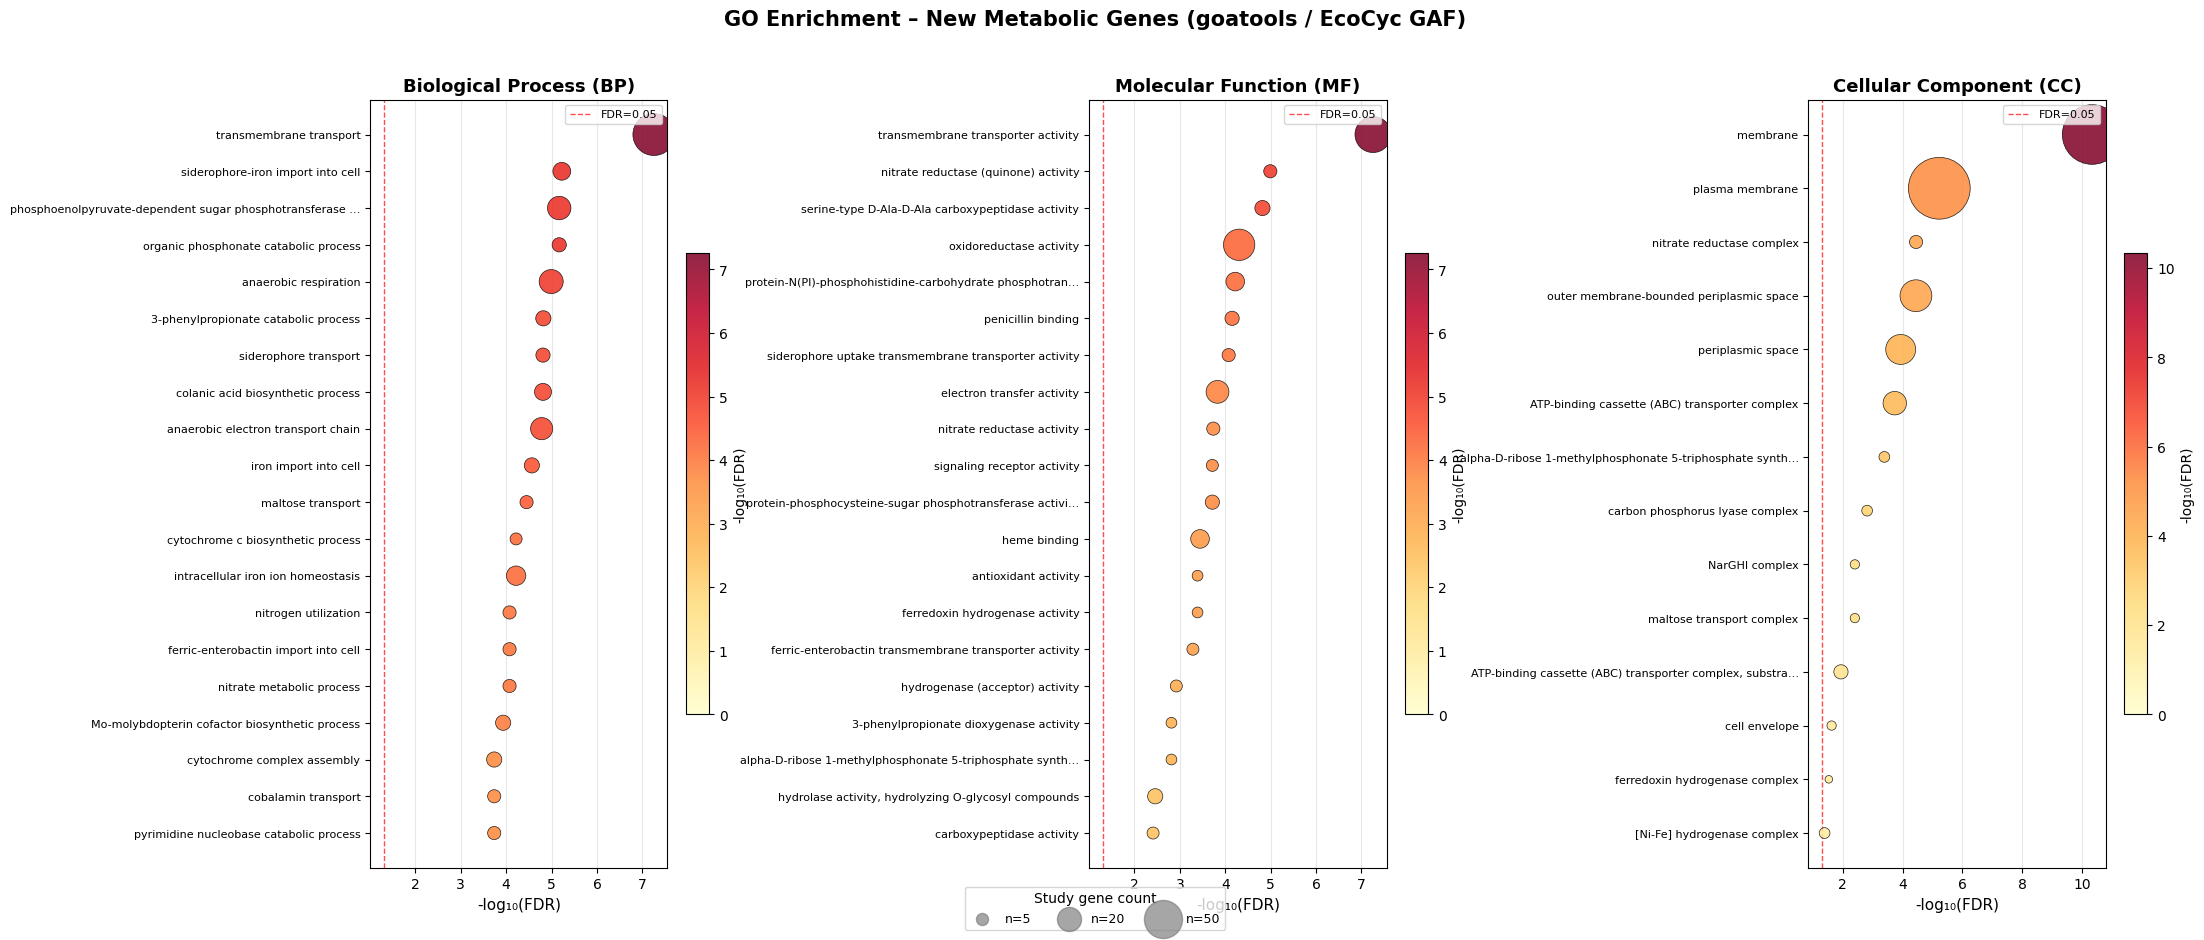

Saved: out/new_genes_functionality/go_enrichment_goatools.svg


In [15]:
import matplotlib.pyplot as plt
import numpy as np

NS_LABELS = {
    "BP": "Biological Process (BP)",
    "MF": "Molecular Function (MF)",
    "CC": "Cellular Component (CC)",
}

if not go_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(22, 9))

    for ax, (ns_key, ns_label) in zip(axes, NS_LABELS.items()):
        ns_data = go_df[go_df["namespace"] == ns_key].head(20).copy()

        if ns_data.empty:
            ax.text(0.5, 0.5, "No significant terms", ha="center", va="center",
                    transform=ax.transAxes, fontsize=12, color="gray")
            ax.set_title(ns_label, fontsize=13, fontweight="bold")
            continue

        ns_data = ns_data.sort_values("p_fdr_bh", ascending=False)
        y_pos   = np.arange(len(ns_data))
        log_p   = -np.log10(ns_data["p_fdr_bh"].clip(lower=1e-300))

        sc = ax.scatter(
            log_p, y_pos,
            s=ns_data["study_count"] * 15,
            c=log_p, cmap="YlOrRd", vmin=0,
            alpha=0.85, edgecolors="black", linewidths=0.5, zorder=3,
        )
        ax.set_yticks(y_pos)
        labels = [t[:55] + "…" if len(t) > 55 else t for t in ns_data["term"]]
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel("-log\u2081\u2080(FDR)", fontsize=11)
        ax.set_title(ns_label, fontsize=13, fontweight="bold")
        ax.axvline(-np.log10(0.05), color="red", ls="--", lw=1, alpha=0.7, label="FDR=0.05")
        ax.legend(fontsize=8)
        ax.grid(axis="x", alpha=0.3)
        plt.colorbar(sc, ax=ax, label="-log\u2081\u2080(FDR)", shrink=0.6)

    # Bubble-size legend
    size_vals = [5, 20, 50]
    legend_handles = [
        plt.scatter([], [], s=s * 15, c="gray", alpha=0.7, label=f"n={s}") for s in size_vals
    ]
    fig.legend(handles=legend_handles, title="Study gene count",
               loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.01), fontsize=9)

    plt.suptitle("GO Enrichment – New Metabolic Genes (goatools / EcoCyc GAF)",
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    save_path = outdir / "go_enrichment_goatools.svg"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
else:
    print("No goatools results to visualise.")

# C). Distribution of new reaction flux to show that they are just low flux reactions. --> indicating the problem

In [66]:
from typing import Iterable, Optional
import plotly.express as px
import dill
def load_sim(
        time_num: int,
        date: str,
        experiment_name: str,
        condition: str,
        experiment_type: str,
):
    # --- Load Sim ---
    time = str(time_num)
    entry = f'{experiment_name}_{time}_{date}'
    folder_path = f'/Users/heenasaqib/dev/vEcoli/out/{experiment_type}/{condition}/{entry}/'

    output = np.load(folder_path + '0_output.npy',allow_pickle='TRUE').item()
    output = output['agents']['0']
    fba = output['listeners']['fba_results']
    bulk = pd.DataFrame(output['bulk'])
    f = open(folder_path + 'agent_steps.pkl', 'rb')
    agent = dill.load(f)
    f.close()

    metabolism = agent['ecoli-metabolism-redux-classic']

    return fba, bulk, metabolism, output

In [59]:
def format_number(x):
    """Format number: scientific notation if |x| < 0.01, else 1 decimal place"""
    if abs(x) < 0.01 and x != 0:
        return f'{x:.2E}'
    else:
        return f'{x:.1f}'

In [79]:
import plotly.graph_objects as go
import numpy as np
def plot_flux_distribution_new_genes(
        fba: dict,
        metabolism: object,
        output: dict,
        in_molar: bool = True,
        show_plot: bool = True,
        save_plot: bool = True,
        save_path: Optional[str] = None,
        renderer: Optional[str] = None,
):
    # --- Load Data ---
    counts_to_molar = output['listeners']['enzyme_kinetics']['counts_to_molar']
    new_fba_rxn_ids = metabolism.parameters['fba_new_reaction_ids']

    reaction_names = metabolism.reaction_names
    if in_molar:
        sim_flux = pd.DataFrame(fba['estimated_fluxes'], columns=reaction_names).mul(counts_to_molar, axis=0)
        unit_label = 'mmol/L/s'
    else:
        sim_flux = pd.DataFrame(fba['estimated_fluxes'], columns=reaction_names)
        unit_label = 'counts/s'

    # --- Process Data for Plot ---
    new_sim_flux = sim_flux[new_fba_rxn_ids]
    sim_flux_mean = new_sim_flux.mean(axis=0)

    # --- Define Custom Bins ---
    if in_molar:
        custom_bins = [0, np.min(counts_to_molar), 1, max(sim_flux.max(axis=0))-10, max(sim_flux.max(axis=0))]
    else:
        custom_bins = [0, 1, 2, max(sim_flux.max(axis=0))/10, max(sim_flux.max(axis=0))/2, max(sim_flux.max(axis=0))]

    binned_data, bin_edges = np.histogram(sim_flux_mean, bins=custom_bins)

    # Create bar chart with custom bins
    fig = go.Figure()

    # bin_centers = [(custom_bins[i] + custom_bins[i+1]) / 2 for i in range(len(custom_bins)-1)]
    # bin_widths = [custom_bins[i+1] - custom_bins[i] for i in range(len(custom_bins)-1)]
    bin_labels = [f'[{format_number(custom_bins[i])}, {format_number(custom_bins[i+1])})'
                  for i in range(len(custom_bins)-1)]

    fig.add_trace(go.Bar(
        x=bin_labels,
        y=binned_data,
        marker=dict(
            color=px.colors.qualitative.Pastel[0],
            line=dict(color='white', width=1)
        ),
        text=binned_data,
        textposition='auto',
    ))

    fig.update_layout(
        template="plotly_white",
        showlegend=False,
        paper_bgcolor='rgba(255, 0, 0, 0)',
        plot_bgcolor='rgba(255, 0, 0, 0)',
        title='Distribution of Mean Fluxes Across Reactions',
        title_font_size=20,
        xaxis_title=f'Mean Estimated Flux ({unit_label})',
        yaxis_title='Count',
    )

    # --- Show and/or Save Plot ---
    if show_plot:
        fig.show(renderer=renderer)

    if save_plot:
        assert save_path is not None, "Please provide a save path to save the plot."

        save_path = f'{save_path}figures/'

        if not os.path.exists(save_path):
            os.makedirs(save_path)
            print(f"Directory '{save_path}' created.")

        fig.write_image(f'{save_path}new_rxns_mean_flux_distribution.svg', width=600, height=600, scale=3)

In [77]:
# import sim
time_num = 2973
date = '2026-05-18'
experiment_name = 'baseline'
condition = 'basal'
experiment_type = 'Fig1'

fba, bulk, metabolism, output = load_sim(time_num, date, experiment_name, condition, experiment_type)

In [78]:
plot_flux_distribution_new_genes(fba, metabolism, output, in_molar=True, show_plot = True, renderer = 'browser', save_plot = True, save_path = folder)

# Scratch

# try to get pathway from ecocyc API

In [ ]:
# Connect to Ecocyc API
s = requests.Session() # create session
# Post login credentials to session:
s.post('https://websvc.biocyc.org/credentials/login/', data={'email':'cellulararchitect@protonmail.com', 'password':'Cellman0451'})

In [54]:
import xmltodict
from tqdm import tqdm
import sys

metabolic_genes = study_ecocyc_ids.copy()
metabolic_genes = study_locus_ids.difference(study_locus_ids & kegg_background).copy()
gene_2_pathways = dict()

for loc_gene in tqdm(metabolic_genes):
    gene = locus_id_to_ecocyc.get(loc_gene, loc_gene)  # convert locus ID to EcoCyc ID if possible
    req = f"https://websvc.biocyc.org/apixml?fn=pathways-of-gene&id=ECOLI:{gene}&detail=none"
    try:
        response = s.get(req, timeout=30)
        if response.status_code != 200:
            sys.exit()
    except:
        continue

    output = xmltodict.parse(response.content)['ptools-xml']

    if 'Pathway' not in output:
        gene_2_pathways[gene] = []
        continue
    elif isinstance(output['Pathway'], list):
        pathways = [p['@frameid'] for p in output['Pathway']]
    elif isinstance(output['Pathway'], dict):
        pathways = [output['Pathway']['@frameid']]
    else:
        pathways = []
    gene_2_pathways[gene] = pathways

100%|██████████| 101/101 [00:05<00:00, 17.53it/s]


In [58]:
output['Pathway']

{'@resource': 'getxml?ECOLI:CARNMET-PWY',
 '@orgid': 'ECOLI',
 '@frameid': 'CARNMET-PWY'}

In [36]:
gene = "EG11557"
req_func = f"https://websvc.biocyc.org/apixml?fn=pathways-of-gene&id=ECOLI:{gene}&detail=none"
response_func = s.get(req_func)
output = xmltodict.parse(response_func.content)['ptools-xml']

In [38]:
output['Pathway']

{'@resource': 'getxml?ECOLI:CARNMET-PWY',
 '@orgid': 'ECOLI',
 '@frameid': 'CARNMET-PWY'}

In [ ]:
output['Gene']['parent']

In [11]:
pathway_id = "CARNMET-PWY"
req_func = f"https://websvc.biocyc.org/apixml?fn=pathways-of-gene&id=ECOLI:{gene}&detail=none"
response_func = s.get(req_func)
output = xmltodict.parse(response_func.content)['ptools-xml']

In [59]:
req_func = f'https://websvc.biocyc.org/getxml?ECOLI:CARNMET-PWY&detail=full'
response_func = s.get(req_func)
output = xmltodict.parse(response_func.content)['ptools-xml']

In [62]:
output['Pathway']

{'@ID': 'ECOLI:CARNMET-PWY',
 '@orgid': 'ECOLI',
 '@frameid': 'CARNMET-PWY',
 '@detail': 'full',
 'parent': [{'Pathway': {'@resource': 'getxml?ECOLI:ANAEROBIC-RESPIRATION',
    '@orgid': 'ECOLI',
    '@frameid': 'ANAEROBIC-RESPIRATION',
    '@class': 'true'}},
  {'Pathway': {'@resource': 'getxml?ECOLI:CARN-DEG',
    '@orgid': 'ECOLI',
    '@frameid': 'CARN-DEG',
    '@class': 'true'}}],
 'synonym': {'@datatype': 'string', '#text': 'L-carnitine respiration'},
 'common-name': {'@datatype': 'string', '#text': 'L-carnitine degradation I'},
 'comment': {'@datatype': 'string',
  '#text': 'In the absence of exogenous electron acceptors like nitrate, nitrite, fumarate,\ndimethyl sulfoxide or trimethylamine-N-oxide, the addition of L-carnitine\nstimulates the anaerobic growth of <i>E. coli</i>.  During anaerobic growth in the\npresence of carbon and nitrogen sources, <i>E. coli</i> is able to catalyze the\ndehydration and reduction of L-carnitine to &gamma;-butyrobetaine via a cyclic\npathway o

In [28]:
req_func = f'https://websvc.biocyc.org/getxml?ECOLI:CARN-DEG&detail=full'
response_func = s.get(req_func)
output = xmltodict.parse(response_func.content)['ptools-xml']
output['Pathway']['parent']

{'Pathway': {'@resource': 'getxml?ECOLI:AMINE-DEG',
  '@orgid': 'ECOLI',
  '@frameid': 'AMINE-DEG',
  '@class': 'true'}}